# Predict Delivery Delays in Supply Chain

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
# k-Nearest Neighbors model
from sklearn.neighbors import KNeighborsClassifier
from sklearn import preprocessing
from sklearn import utils
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
import operator
%matplotlib inline

In [2]:
#Data loading
os.chdir("C:\\Users\\ramia\\OneDrive\\Documents\\Etudes\\L3_Informatique\\ProjetMachineLearning\\ProjectWarehouse")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
filename ="DataCoSupplyChainDataset.csv"
fileDescription = "DescriptionDataCoSupplyChain.xls"
#The columns are separated by commas, the encoding is not utf-8
description_df = pd.read_csv(fileDescription, sep=',')
dataset = pd.read_csv(filename, sep=',', encoding="latin-1")
dataset.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
#(lines,columns)
dataset.shape[:]

(180519, 53)

In [32]:
# Description of the dataset columns
description_df

,FIELDS,DESCRIPTION
0,Type,: Type of transaction made
1,Days for shipping (real),: Actual shipping days of the purchased product
2,Days for shipment (scheduled),: Days of scheduled delivery of the purchased...
3,Benefit per order,: Earnings per order placed
4,Sales per customer,: Total sales per customer made per customer
5,Delivery Status,: Delivery status of orders: Advance shipping...
6,Late_delivery_risk,: Categorical variable that indicates if send...
7,Category Id,: Product category code
8,Category Name,: Description of the product category
9,Customer City,: City where the customer made the purchase


In [33]:
# Drop useless columns from the dataset
dataset = dataset.drop(columns=[
    'Category Id', 'Category Name','Customer Email','Customer Fname', 'Customer Id',
    'Customer Lname', 'Customer Password', 'Order Customer Id','Order Id', 'Order Item Cardprod Id',
    'Order Item Id','Product Description','Product Image'
])
dataset.head(10)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Customer City,Customer Country,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Caguas,Puerto Rico,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,1/31/2018 22:56,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Caguas,Puerto Rico,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,1/13/2018 12:27,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,San Jose,EE. UU.,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,1/13/2018 12:06,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Los Angeles,EE. UU.,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,1/13/2018 11:45,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Caguas,Puerto Rico,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,1/13/2018 11:24,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class
5,TRANSFER,6,4,18.580000,294.980011,Shipping canceled,0,Tonawanda,EE. UU.,Consumer,NY,2122 Hazy Corner,14150.0,2,Fitness,43.013969,-78.879066,Pacific Asia,Toowoomba,Australia,1/13/2018 11:03,32.779999,0.10,327.75,0.06,1,327.75,294.980011,18.580000,Oceania,Queensland,CANCELED,NaN,1360,73,Smart watch,327.75,0,1/19/2018 11:03,Standard Class
6,DEBIT,2,1,95.180000,288.420013,Late delivery,1,Caguas,Puerto Rico,Home Office,PR,1879 Green Pine Bank,725.0,2,Fitness,18.242538,-66.037056,Pacific Asia,Guangzhou,China,1/13/2018 10:42,39.330002,0.12,327.75,0.33,1,327.75,288.420013,95.180000,Eastern Asia,Guangdong,COMPLETE,NaN,1360,73,Smart watch,327.75,0,1/15/2018 10:42,First Class
7,TRANSFER,2,1,68.430000,285.140015,Late delivery,1,Miami,EE. UU.,Corporate,FL,7595 Cotton Log Row,33162.0,2,Fitness,25.928869,-80.162872,Pacific Asia,Guangzhou,China,1/13/2018 10:21,42.610001,0.13,327.75,0.24,1,327.75,285.140015,68.430000,Eastern Asia,Guangdong,PROCESSING,NaN,1360,73,Smart watch,327.75,0,1/15/2018 10:21,First Class
8,CASH,3,2,133.720001,278.589996,Late delivery,1,Caguas,Puerto Rico,Corporate,PR,2051 Dusty Route,725.0,2,Fitness,18.233223,-66.037056,Pacific Asia,Guangzhou,China,1/13/2018 10:00,49.160000,0.15,327.75,0.48,1,327.75,278.589996,133.720001,Eastern Asia,Guangdong,CLOSED,NaN,1360,73,Smart watch,327.75,0,1/16/2018 10:00,Second Class
9,CASH,2,1,132.149994,275.309998,Late delivery,1,San Ramon,EE. UU.,Corporate,CA,9139 Blue Blossom Court,94583.0,2,Fitness,37.773991,-121.966629,Pacific Asia,Guangzhou,China,1/13/2018 9:39,52.439999,0.16,327.75,0.48,1,327.75,275.309998,132.149994,Eastern Asia,Guangdong,CLOSE

In [34]:
# Remove columns that contain information only available during or after delivery.
# Since these features are not known before shipment, they cannot be used for predicting late delivery risk.
dataset = dataset.drop(columns=[
    'Days for shipping (real)', 'Delivery Status','Order Status'
])
dataset.head(10)

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Customer City,Customer Country,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Zipcode,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,4,91.250000,314.640015,0,Caguas,Puerto Rico,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,1/31/2018 22:56,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,NaN,1360,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,4,-249.089996,311.359985,1,Caguas,Puerto Rico,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,1/13/2018 12:27,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,NaN,1360,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,-247.779999,309.720001,0,San Jose,EE. UU.,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,1/13/2018 12:06,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,NaN,1360,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,4,22.860001,304.809998,0,Los Angeles,EE. UU.,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,1/13/2018 11:45,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,NaN,1360,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,4,134.210007,298.250000,0,Caguas,Puerto Rico,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,1/13/2018 11:24,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,NaN,1360,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class
5,TRANSFER,4,18.580000,294.980011,0,Tonawanda,EE. UU.,Consumer,NY,2122 Hazy Corner,14150.0,2,Fitness,43.013969,-78.879066,Pacific Asia,Toowoomba,Australia,1/13/2018 11:03,32.779999,0.10,327.75,0.06,1,327.75,294.980011,18.580000,Oceania,Queensland,NaN,1360,73,Smart watch,327.75,0,1/19/2018 11:03,Standard Class
6,DEBIT,1,95.180000,288.420013,1,Caguas,Puerto Rico,Home Office,PR,1879 Green Pine Bank,725.0,2,Fitness,18.242538,-66.037056,Pacific Asia,Guangzhou,China,1/13/2018 10:42,39.330002,0.12,327.75,0.33,1,327.75,288.420013,95.180000,Eastern Asia,Guangdong,NaN,1360,73,Smart watch,327.75,0,1/15/2018 10:42,First Class
7,TRANSFER,1,68.430000,285.140015,1,Miami,EE. UU.,Corporate,FL,7595 Cotton Log Row,33162.0,2,Fitness,25.928869,-80.162872,Pacific Asia,Guangzhou,China,1/13/2018 10:21,42.610001,0.13,327.75,0.24,1,327.75,285.140015,68.430000,Eastern Asia,Guangdong,NaN,1360,73,Smart watch,327.75,0,1/15/2018 10:21,First Class
8,CASH,2,133.720001,278.589996,1,Caguas,Puerto Rico,Corporate,PR,2051 Dusty Route,725.0,2,Fitness,18.233223,-66.037056,Pacific Asia,Guangzhou,China,1/13/2018 10:00,49.160000,0.15,327.75,0.48,1,327.75,278.589996,133.720001,Eastern Asia,Guangdong,NaN,1360,73,Smart watch,327.75,0,1/16/2018 10:00,Second Class
9,CASH,1,132.149994,275.309998,1,San Ramon,EE. UU.,Corporate,CA,9139 Blue Blossom Court,94583.0,2,Fitness,37.773991,-121.966629,Pacific Asia,Guangzhou,China,1/13/2018 9:39,52.439999,0.16,327.75,0.48,1,327.75,275.309998,132.149994,Eastern Asia,Guangdong,NaN,1360,73,Smart watch,327.75,0,1/15/2018 9:39,First Class


In [35]:
#We check that there are no null values in the dataset
dataset.isnull().sum()

Type                                  0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Late_delivery_risk                    0
Customer City                         0
Customer Country                      0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0
Order City                            0
Order Country                         0
order date (DateOrders)               0
Order Item Discount                   0
Order Item Discount Rate              0
Order Item Product Price              0
Order Item Profit Ratio               0
Order Item Quantity                   0
Sales                                 0


In [36]:
# Remove columns that contain null values and can be safely omitted from the analysis
dataset = dataset.drop(columns=[
    'Customer Zipcode','Order Zipcode'
])
dataset.isnull().sum()

Type                             0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Late_delivery_risk               0
Customer City                    0
Customer Country                 0
Customer Segment                 0
Customer State                   0
Customer Street                  0
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
order date (DateOrders)          0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product Price         0
Order Item Profit Ratio          0
Order Item Quantity              0
Sales                            0
Order Item Total                 0
Order Profit Per Order           0
Order Region                     0
Order State                      0
Product Card Id     

In [37]:
#(lines,columns)
N=dataset.shape[0]
D=dataset.shape[1]
dataset.shape[:]

(180519, 35)

In [38]:
# Display the first 10 rows of the dataset
dataset.head(10)

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Customer City,Customer Country,Customer Segment,Customer State,Customer Street,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,4,91.250000,314.640015,0,Caguas,Puerto Rico,Consumer,PR,5365 Noble Nectar Island,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,1/31/2018 22:56,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,1360,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,4,-249.089996,311.359985,1,Caguas,Puerto Rico,Consumer,PR,2679 Rustic Loop,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,1/13/2018 12:27,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,1360,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,-247.779999,309.720001,0,San Jose,EE. UU.,Consumer,CA,8510 Round Bear Gate,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,1/13/2018 12:06,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,1360,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,4,22.860001,304.809998,0,Los Angeles,EE. UU.,Home Office,CA,3200 Amber Bend,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,1/13/2018 11:45,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,1360,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,4,134.210007,298.250000,0,Caguas,Puerto Rico,Corporate,PR,8671 Iron Anchor Corners,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,1/13/2018 11:24,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,1360,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class
5,TRANSFER,4,18.580000,294.980011,0,Tonawanda,EE. UU.,Consumer,NY,2122 Hazy Corner,2,Fitness,43.013969,-78.879066,Pacific Asia,Toowoomba,Australia,1/13/2018 11:03,32.779999,0.10,327.75,0.06,1,327.75,294.980011,18.580000,Oceania,Queensland,1360,73,Smart watch,327.75,0,1/19/2018 11:03,Standard Class
6,DEBIT,1,95.180000,288.420013,1,Caguas,Puerto Rico,Home Office,PR,1879 Green Pine Bank,2,Fitness,18.242538,-66.037056,Pacific Asia,Guangzhou,China,1/13/2018 10:42,39.330002,0.12,327.75,0.33,1,327.75,288.420013,95.180000,Eastern Asia,Guangdong,1360,73,Smart watch,327.75,0,1/15/2018 10:42,First Class
7,TRANSFER,1,68.430000,285.140015,1,Miami,EE. UU.,Corporate,FL,7595 Cotton Log Row,2,Fitness,25.928869,-80.162872,Pacific Asia,Guangzhou,China,1/13/2018 10:21,42.610001,0.13,327.75,0.24,1,327.75,285.140015,68.430000,Eastern Asia,Guangdong,1360,73,Smart watch,327.75,0,1/15/2018 10:21,First Class
8,CASH,2,133.720001,278.589996,1,Caguas,Puerto Rico,Corporate,PR,2051 Dusty Route,2,Fitness,18.233223,-66.037056,Pacific Asia,Guangzhou,China,1/13/2018 10:00,49.160000,0.15,327.75,0.48,1,327.75,278.589996,133.720001,Eastern Asia,Guangdong,1360,73,Smart watch,327.75,0,1/16/2018 10:00,Second Class
9,CASH,1,132.149994,275.309998,1,San Ramon,EE. UU.,Corporate,CA,9139 Blue Blossom Court,2,Fitness,37.773991,-121.966629,Pacific Asia,Guangzhou,China,1/13/2018 9:39,52.439999,0.16,327.75,0.48,1,327.75,275.309998,132.149994,Eastern Asia,Guangdong,1360,73,Smart watch,327.75,0,1/15/2018 9:39,First Class


In [39]:
# Add a new column representing the duration between the order date and the shipping date

# Convert the relevant columns to datetime format
shipping_date = pd.to_datetime(dataset['shipping date (DateOrders)'])
order_date = pd.to_datetime(dataset['order date (DateOrders)'])

# Calculate the time difference in hours between the order date and the shipping date
order_to_shipment_hours = ((shipping_date - order_date).dt.total_seconds() / 3600).astype(int)

# Add the computed time as a new column in the dataset
dataset["Order_to_Shipment_Hours"] = order_to_shipment_hours.values

# Display the first 10 rows to verify
dataset.head(10)

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Customer City,Customer Country,Customer Segment,Customer State,Customer Street,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Order_to_Shipment_Hours
0,DEBIT,4,91.250000,314.640015,0,Caguas,Puerto Rico,Consumer,PR,5365 Noble Nectar Island,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,1/31/2018 22:56,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,1360,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class,72
1,TRANSFER,4,-249.089996,311.359985,1,Caguas,Puerto Rico,Consumer,PR,2679 Rustic Loop,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,1/13/2018 12:27,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,1360,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class,120
2,CASH,4,-247.779999,309.720001,0,San Jose,EE. UU.,Consumer,CA,8510 Round Bear Gate,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,1/13/2018 12:06,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,1360,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class,96
3,DEBIT,4,22.860001,304.809998,0,Los Angeles,EE. UU.,Home Office,CA,3200 Amber Bend,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,1/13/2018 11:45,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,1360,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class,72
4,PAYMENT,4,134.210007,298.250000,0,Caguas,Puerto Rico,Corporate,PR,8671 Iron Anchor Corners,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,1/13/2018 11:24,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,1360,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class,48
5,TRANSFER,4,18.580000,294.980011,0,Tonawanda,EE. UU.,Consumer,NY,2122 Hazy Corner,2,Fitness,43.013969,-78.879066,Pacific Asia,Toowoomba,Australia,1/13/2018 11:03,32.779999,0.10,327.75,0.06,1,327.75,294.980011,18.580000,Oceania,Queensland,1360,73,Smart watch,327.75,0,1/19/2018 11:03,Standard Class,144
6,DEBIT,1,95.180000,288.420013,1,Caguas,Puerto Rico,Home Office,PR,1879 Green Pine Bank,2,Fitness,18.242538,-66.037056,Pacific Asia,Guangzhou,China,1/13/2018 10:42,39.330002,0.12,327.75,0.33,1,327.75,288.420013,95.180000,Eastern Asia,Guangdong,1360,73,Smart watch,327.75,0,1/15/2018 10:42,First Class,48
7,TRANSFER,1,68.430000,285.140015,1,Miami,EE. UU.,Corporate,FL,7595 Cotton Log Row,2,Fitness,25.928869,-80.162872,Pacific Asia,Guangzhou,China,1/13/2018 10:21,42.610001,0.13,327.75,0.24,1,327.75,285.140015,68.430000,Eastern Asia,Guangdong,1360,73,Smart watch,327.75,0,1/15/2018 10:21,First Class,48
8,CASH,2,133.720001,278.589996,1,Caguas,Puerto Rico,Corporate,PR,2051 Dusty Route,2,Fitness,18.233223,-66.037056,Pacific Asia,Guangzhou,China,1/13/2018 10:00,49.160000,0.15,327.75,0.48,1,327.75,278.589996,133.720001,Eastern Asia,Guangdong,1360,73,Smart watch,327.75,0,1/16/2018 10:00,Second Class,72
9,CASH,1,132.149994,275.309998,1,San Ramon,EE. UU.,Corporate,CA,9139 Blue Blossom Court,2,Fitness,37.773991,-121.966629,Pacific Asia,Guangzhou,China,1/13/2018 9:39,52.439999,0.16,327.75,0.48,1,327.75,275.309998,132.149994,Eastern Asia,Guangdong,1360,73,Smart watch,327.75,0,1/15/2018 9:39,First Class,48


In [40]:
#Data type for every column of the data set
dataset.dtypes

Type                              object
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Late_delivery_risk                 int64
Customer City                     object
Customer Country                  object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market                            object
Order City                        object
Order Country                     object
order date (DateOrders)           object
Order Item Discount              float64
Order Item Discount Rate         float64
Order Item Product Price         float64
Order Item Profit Ratio          float64
Order Item Quantity                int64
Sales                            float64
Order Item Total

In [41]:
#We define all the features that are objects
#Use LabelEncoder to convert 'Object' columns into 'int' columns
obj = [name for name in dataset.columns if dataset[name].dtype == 'object']

le=LabelEncoder()
for i in list(obj):
    dataset[i]=le.fit_transform(dataset[i])
dataset.head(5)

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Customer City,Customer Country,Customer Segment,Customer State,Customer Street,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Order_to_Shipment_Hours
0,1,4,91.250000,314.640015,0,66,1,0,36,3683,2,4,18.251453,-66.037056,3,331,70,5961,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,15,475,1360,73,78,327.75,0,27149,3,72
1,3,4,-249.089996,311.359985,1,66,1,0,36,1400,2,4,18.279451,-66.037064,3,391,69,1147,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,13,841,1360,73,78,327.75,0,2209,3,120
2,0,4,-247.779999,309.720001,0,452,0,0,5,6217,2,4,37.292233,-121.881279,3,391,69,1146,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,13,841,1360,73,78,327.75,0,1980,3,96
3,1,4,22.860001,304.809998,0,285,0,2,5,1803,2,4,34.125946,-118.291016,3,3226,8,1145,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,11,835,1360,73,78,327.75,0,1752,3,72
4,2,4,134.210007,298.250000,0,66,1,1,36,6345,2,4,18.253769,-66.037048,3,3226,8,1144,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,11,835,1360,73,78,327.75,0,1528,3,48


In [42]:
# Separate the target column from the features
target = dataset["Late_delivery_risk"]
features = dataset.drop("Late_delivery_risk", axis=1)

# Standardize only the feature columns using z-score normalization:
# This transforms each feature so that it has mean = 0 and standard deviation = 1.
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Convert the scaled features back into a DataFrame
df_scaled = pd.DataFrame(features_scaled, columns=features.columns)

# Add back the target column without scaling it
df_scaled["Late_delivery_risk"] = target.values

df_scaled.head(10)

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Customer City,Customer Country,Customer Segment,Customer State,Customer Street,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Order_to_Shipment_Hours,Late_delivery_risk
0,-0.678772,0.777152,0.663343,1.095708,-0.795294,1.265761,-0.866396,0.754590,-0.009828,-2.113536,0.301194,-1.168631,0.880813,0.775657,-1.509322,0.115987,-1.539111,-0.346534,-0.875782,1.334822,0.362801,-0.775836,0.93729,1.095708,0.663343,0.411131,-0.247183,1.983945,2.630978,0.829945,1.334822,0.0,-0.356248,0.695051,-0.308414,0
1,1.331997,0.777152,-2.595582,1.068384,-0.795294,1.265761,-0.866396,0.754590,-1.071270,-2.113536,0.301194,-1.165778,0.880812,0.775657,-1.449591,0.092094,-1.796759,-0.196082,-0.733767,1.334822,-1.972275,-0.775836,0.93729,1.068384,-2.595582,0.124731,0.943905,1.983945,2.630978,0.829945,1.334822,0.0,-1.733739,0.695051,0.928147,1
2,-1.684156,0.777152,-2.583038,1.054722,1.603264,-0.790039,-0.866396,-1.620781,1.168312,-2.113536,0.301194,0.771609,-1.724690,0.775657,-1.449591,0.092094,-1.796813,-0.120855,-0.591751,1.334822,-1.972275,-0.775836,0.93729,1.054722,-2.583038,0.124731,0.943905,1.983945,2.630978,0.829945,1.334822,0.0,-1.746387,0.695051,0.309866,0
3,-0.678772,0.777152,0.008474,1.013820,0.565546,-0.790039,1.756879,-1.620781,-0.883902,-2.113536,0.301194,0.448967,-1.557181,0.775657,1.372709,-1.365398,-1.796867,0.104366,-0.449736,1.334822,-0.087076,-0.775836,0.93729,1.013820,0.008474,-0.161670,0.924378,1.983945,2.630978,0.829945,1.334822,0.0,-1.758980,0.695051,-0.308414,0
4,0.326612,0.777152,1.074706,0.959174,-0.795294,1.265761,0.445241,0.754590,1.227824,-2.113536,0.301194,-1.168395,0.880813,0.775657,1.372709,-1.365398,-1.796920,0.405271,-0.165706,1.334822,0.705564,-0.775836,0.93729,0.959174,1.074706,-0.161670,0.924378,1.983945,2.630978,0.829945,1.334822,0.0,-1.771352,0.695051,-0.926694,0
5,1.331997,0.777152,-0.032509,0.931933,1.932600,-0.790039,-0.866396,0.371466,-1.273050,-2.113536,0.301194,1.354650,0.281648,0.775657,1.353794,-1.365398,-1.796974,0.555724,-0.023691,1.334822,-0.129922,-0.775836,0.93729,0.931933,-0.032509,-0.161670,0.924378,1.983945,2.630978,0.829945,1.334822,0.0,-1.722140,0.695051,1.546427,0
6,-0.678772,-1.405546,0.700974,0.877287,-0.795294,1.265761,1.756879,0.754590,-1.366037,-2.113536,0.301194,-1.169540,0.880813,0.775657,-0.608377,-0.815852,-1.797027,0.856172,0.260339,1.334822,0.448492,-0.775836,0.93729,0.877287,0.700974,-0.734471,-0.536820,1.983945,2.630978,0.829945,1.334822,0.0,-1.771573,-2.029950,-0.926694,1
7,1.331997,-1.405546,0.444830,0.849963,0.770604,-0.790039,0.445241,-1.237657,0.829376,-2.113536,0.301194,-0.386309,0.221750,0.775657,-0.608377,-0.815852,-1.797081,1.006624,0.402355,1.334822,0.255687,-0.775836,0.93729,0.849963,0.444830,-0.734471,-0.536820,1.983945,2.630978,0.829945,1.334822,0.0,-1.771628,-2.029950,-0.926694,1
8,-1.684156,-0.677980,1.070014,0.795399,-0.795294,1.265761,0.445241,0.754590,-1.299552,-2.113536,0.301194,-1.170489,0.880813,0.775657,-0.608377,-0.815852,-1.797134,1.307072,0.686385,1.334822,0.769832,-0.775836,0.93729,0.795399,1.070014,-0.734471,-0.536820,1.983945,2.630978,0.829945,1.334822,0.0,-1.759256,-0.213283,-0.308414,1
9,-1.684156,-1.405546,1.054980,0.768076,1.634334,-0.790039,0.445241,-1.620781,1.411472,-2.113536,0.301194,0.820700,-1.728673,0.775657,-0.608377,-0.815852,-1.793709,1.457524,0.828400,1.334822,0.769832,-0.775836,0.93729,0.768076,1.054980,-0.734471,-0.536820,1.983945,2.630978,0.829945,1.334822,0.0,-1.768203,-2.029950,-0.926694,1


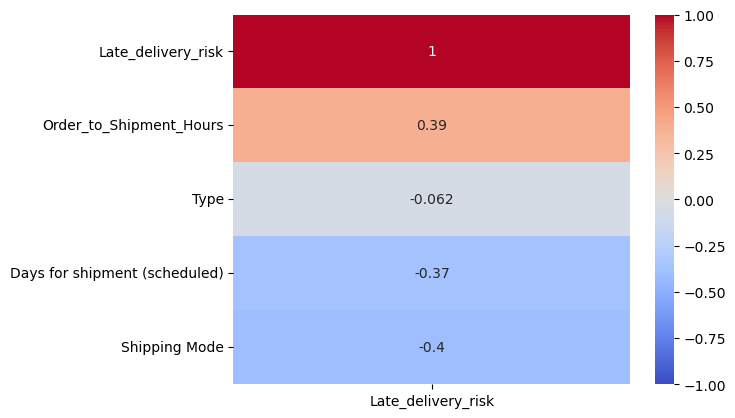

In [43]:
# Correlation with Late_delivery_risk
correlations = df_scaled.corr(numeric_only=True)["Late_delivery_risk"]

# Keep only significant correlations
correlations_filtered = correlations[(correlations <= -0.05) | (correlations >= 0.05)]

# Sort
correlations_filtered = correlations_filtered.sort_values(ascending=False)

# Heatmap
sns.heatmap(
    correlations_filtered.to_frame(),
    annot=True,
    cmap="coolwarm",
    vmin=-1, vmax=1
)

plt.show()

In [44]:
# We keep these four columns because they are well correlated with the target
X = pd.DataFrame(np.c_[dataset['Order_to_Shipment_Hours'], 
                       dataset['Days for shipment (scheduled)'], 
                       dataset['Shipping Mode'],
                       dataset['Type']], 
                 columns=['Order_to_Shipment_Hours', 
                          'Days for shipment (scheduled)', 
                          'Shipping Mode',
                          'Type'])

# The variable we are trying to predict
Y = dataset['Late_delivery_risk']
 
# Training set and test set
from sklearn.model_selection import train_test_split

# We create our training set (80% of the data) and test set (20% of the data)
# We set a value for random_state so that the split remains the same at each execution
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=5)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(144415, 4)
(36104, 4)
(144415,)
(36104,)


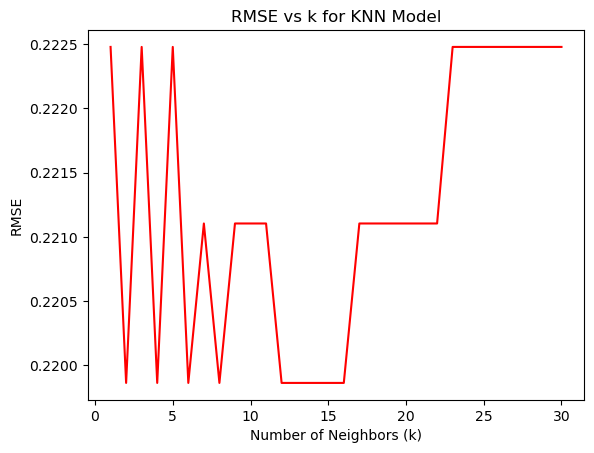

In [45]:
# k-Nearest Neighbors model
# We evaluate the hyperparameter k of the KNeighbors model from 1 to 30

maxNeighbors = 30

def kChoice(x, y, k):
    # Create a KNN model with k neighbors
    model = KNeighborsClassifier(n_neighbors=k)
    
    # Train the model using the training dataset
    model.fit(X_train, Y_train)
    
    # Predict on the training data
    y_pred = model.predict(X_train)
    
    # Compute the Root Mean Squared Error between true labels and predictions
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    # Sort predicted values according to x (first element of each pair)
    sort_axis = operator.itemgetter(0)
    sorted_zip = sorted(zip(x, y_pred), key=sort_axis)
    
    # Unzip sorted data
    x_sorted, y_pred_sorted = zip(*sorted_zip)
    
    # Return RMSE and sorted values
    return rmse, x_sorted, y_pred_sorted

# Lists to store RMSE and sorted prediction results for each k
rmse_list = np.zeros(maxNeighbors)
x_sorted_list = [None] * maxNeighbors
y_pred_sorted_list = [None] * maxNeighbors

# Loop through k from 1 to maxNeighbors and compute metrics
for i in np.arange(1, maxNeighbors + 1):
    rmse_list[i-1], x_sorted_list[i-1], y_pred_sorted_list[i-1] = kChoice(X_train, Y_train, i)

# Plot RMSE as a function of k
plt.plot(np.arange(1, maxNeighbors + 1), rmse_list, color='r')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("RMSE")
plt.title("RMSE vs k for KNN Model")
plt.show()

In [47]:
# Create a KNN model with 14 neighbors
model = KNeighborsClassifier(n_neighbors=14)

# Train the model using the training data
model.fit(X_train, Y_train)

# Make predictions on the training set
y_pred = model.predict(X_train)

# Compute the Root Mean Squared Error (RMSE) between true labels and predictions
rmse = np.sqrt(mean_squared_error(Y_train, y_pred))
print("RMSE:", rmse)

# Compute the classification accuracy in percentage
accuracy = accuracy_score(Y_train, y_pred) * 100
print("Taux de réussite:", accuracy.round(2), "%")

RMSE: 0.21986326180900173
Taux de réussite: 95.17 %


In [49]:
# Make predictions on the test set using the model already trained on the training data
y_pred_test = model.predict(X_test)

# Compute RMSE on the test set
rmse_test = np.sqrt(mean_squared_error(Y_test, y_pred_test))
print("RMSE (test):", rmse_test)

# Compute accuracy on the test set in percentage
accuracy_test = accuracy_score(Y_test, y_pred_test) * 100
print("Taux de réussite:", accuracy_test.round(2), "%")

RMSE (test): 0.2165463255316585
Taux de réussite: 95.31 %
